# GSoC 2026 | ML4Sci EXXA | General Test
## Unsupervised Clustering of Protoplanetary Disks

**Candidate:** Divyansh Soni

---

### Core Idea

I use Variational Autoencoder in two distinct ways simultaneously:

**Latent space as a morphology descriptor**
The VAE is trained to reconstruct a blurred version of the input , this deliberately erases planet signals so the latent space encodes only ring morphology: shape, symmetry, brightness profile, and inclination. These latent vectors drive the clustering.

**Reconstruction residual as a planet detector**
Because the VAE reconstructs disk background only, anything compact and point-like that it fails to reconstruct surfaces in the residual (input − reconstruction). A LoG-based pipeline then filters these residual peaks by compactness, contrast, and ring contamination to produce planet candidate detections.

---

### Pipeline Overview

```
FITS Files → Preprocessing (arcsinh · star mask · radial subtraction · 128×128)
           → DiskVAE Training (blurred target · ring-aware losses · radial conditioning)
           → Residual Extraction (input − reconstruction → planet candidates)
           → Latent Extraction (μ per image → 128-dim morphology descriptor)
           → Planet Detection (LoG · MAD threshold · compactness · contrast filter)
           → Clustering (primary by planet count · GMM subclusters · UMAP)
           → Interactive Viewer (browse images per morphological subcluster)
```

![general_test/general_test_pipeline_v2 (1).svg](<general_test_pipeline_v2 (1).svg>)

## 1. Imports & Device Setup

All dependencies loaded upfront. No external installs required beyond the standard ML stack and `astropy`.

In [2]:

import os
import csv
import math
import numpy as np
from scipy.ndimage import (gaussian_filter, median_filter, gaussian_laplace,
                            label, uniform_filter, center_of_mass)

from astropy.io import fits

from skimage.feature import peak_local_max

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

All hyperparameters in one place. Set `TRAIN_FROM_SCRATCH = True` to retrain from scratch, `False` to load the pre-trained checkpoint.

In [1]:
TRAIN_FROM_SCRATCH = False         # set True to retrain from scratch

# Data
DATA_PATH       = "continuum_data_subset"
CHECKPOINT_PATH = "disk_vae_checkpoint.pth"

# Architecture
LATENT_DIM      = 128

# Training
EPOCHS          = 800
BATCH_SIZE      = 32
LR              = 3e-4
WEIGHT_DECAY    = 1e-5
BETA_KL_MAX     = 1e-3
BETA_WARMUP     = 100

# Planet detection (tuned via interactive tuner)
PLANET_FWHM            = 3.0
CENTER_MASK            = 0
EDGE_MASK              = 2
MIN_PLANET_SEP         = 2
MAX_PEAKS              = 8
MAD_MULT               = 3.6
PERCENTILE_THR         = 99
COMPACTNESS_THR        = 0.19
CONTRAST_THR           = 3.8
ANNULUS_HIGH_FRAC_THR  = 0.10
RING_CONTAMINATION_THR = 0.18
CORE_MIN               = 1
CORE_MAX               = 8
FAINT_THR              = 0.02
PAIR_BRIGHTNESS_RATIO  = 0.4
GROUP_RADIUS           = 2

# Clustering
SUBCLUSTER_MAX_K              = {0: 5, 1: 5, 2: 5}
MIN_SAMPLES_FOR_CLUSTERING    = 5
PCA_COMPONENTS_FOR_CLUSTERING = 8
RANDOM_SEED                   = 42

## 3. Data Discovery

I recursively collect all FITS file paths from the dataset directory. Unlike the image test, there is no train/test split here  the full dataset is used for unsupervised clustering.

In [3]:
import random
import os

data_path = "continuum_data_subset"

files = []

for root, dirs, fs in os.walk(data_path):
    for f in fs:
        if f.endswith(".fits"):
            files.append(os.path.join(root,f))

print(f"Total FITS files found: {len(files)}")

Total FITS files found: 150


## 4. Preprocessing

Raw FITS frames go through a pipeline designed to preserve disk morphology while correcting acquisition artefacts:

- **NaN and Inf removal** : replaces invalid values with zero
- **Center crop** : retains the central 80% of the frame, removing edge artefacts
- **Arcsinh stretch** : compresses the extreme dynamic range of ALMA flux values and lifts faint ring features
- **Central star masking** : replaces the saturated star core with the local annulus median
- **Normalization** : scales to [0, 1] per image

`subtract_radial_profile()` additionally removes the smooth radial brightness gradient using per-ring median subtraction, making it robust to bright planet spots that would otherwise bias the background model.

100%|██████████| 150/150 [00:04<00:00, 33.33it/s]


Dataset shape     : torch.Size([150, 1, 128, 128])
Raw image[0] shape: (600, 600)


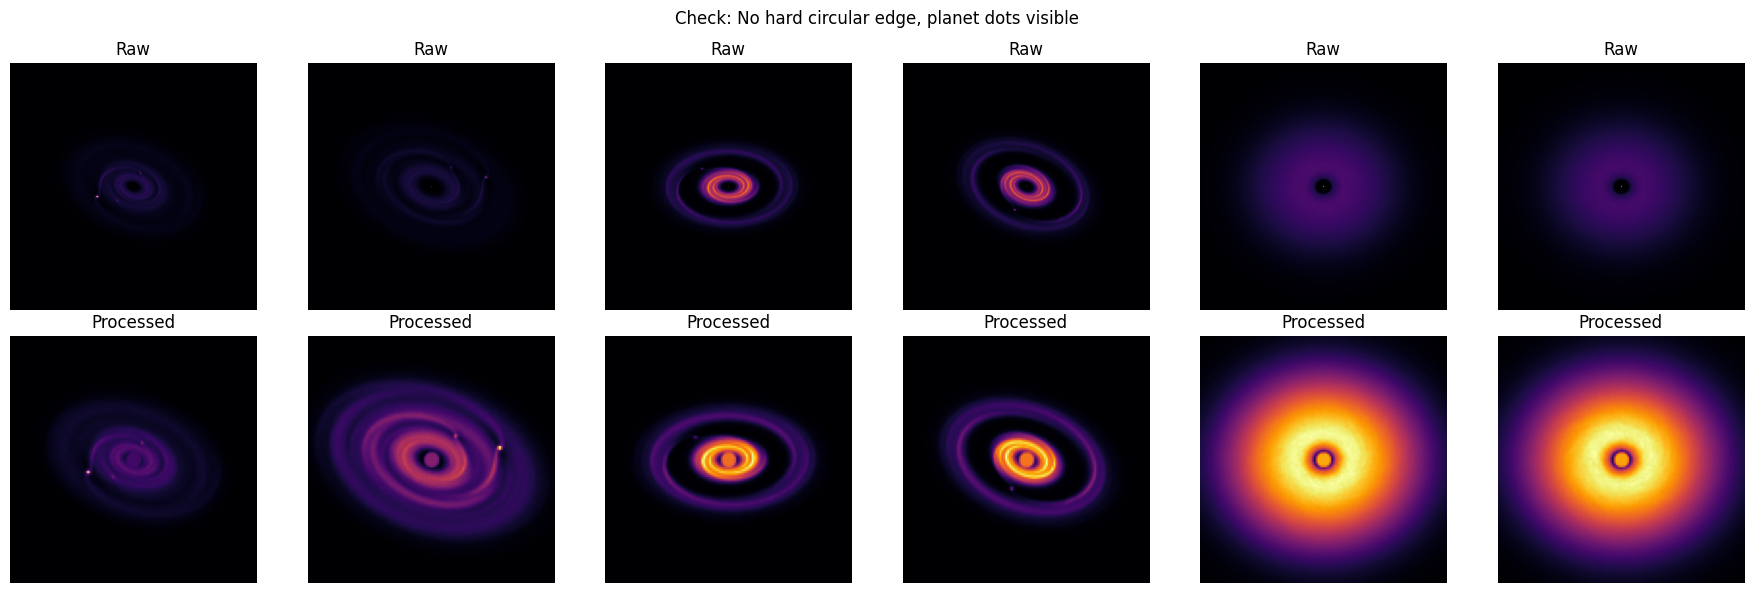

In [4]:
raw_images = []
processed_images = []
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


def subtract_radial_profile(data, valid_radius=None):
    """
    Subtracts a radial background profile from a 2D image using per-ring
    median values, making it robust to bright localized sources (e.g. planets).

    Args:
        data         : 2D numpy array (single FITS frame)
        valid_radius : radial extent (pixels) of the profile model;
                       defaults to the smaller half-dimension

    Returns:
        Residual 2D array with radial background removed
    """
    h, w   = data.shape
    cx, cy = h // 2, w // 2
    y, x   = np.ogrid[:h, :w]
    r      = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    r_int  = r.astype(int)
    r_max  = valid_radius if valid_radius else min(cx, cy)

    ring_model = np.zeros_like(data)
    for i in range(r_max):
        annulus = (r_int == i)
        if annulus.any():
            ring_model[annulus] = np.median(data[annulus])

    return data - ring_model


def preprocess_fits(data, mask_radius=15):
    """
    Minimal preprocessing pipeline that preserves disk morphology for
    downstream clustering. Corrects only unavoidable acquisition artefacts.

    Steps:
        1. Replace NaNs / Infs with 0
        2. Center-crop to 80% of frame
        3. Arcsinh stretch to compress bright rings and lift faint features
        4. Replace central star bleed with local annulus median
        5. Normalize to [0, 1]

    Args:
        data        : 2D numpy float array (raw FITS frame)
        mask_radius : pixel radius of the central star mask

    Returns:
        Preprocessed 2D float32 array
    """
    data   = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    h, w   = data.shape
    cx, cy = h // 2, w // 2

    crop   = min(int(min(h, w) * 0.8), min(h, w))
    data   = data[cx - crop // 2 : cx + crop // 2,
                  cy - crop // 2 : cy + crop // 2]
    h, w   = data.shape
    cx, cy = h // 2, w // 2

    data   = np.arcsinh(5 * (data - np.min(data)))

    y, x      = np.ogrid[:h, :w]
    dist      = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    star_mask = dist < mask_radius
    data[star_mask] = np.median(data[(dist >= mask_radius) & (dist < mask_radius * 3)])

    data = data - np.min(data)
    if data.max() > 0:
        data /= data.max()

    return data.astype(np.float32)


raw_images, images, names = [], [], []

for path in tqdm(files):
    try:
        with fits.open(path) as hdul:
            data = hdul[0].data

            while data.ndim > 2:
                data = data[0]

            raw = np.nan_to_num(data).astype(np.float32)
            raw_images.append(raw)

            processed = preprocess_fits(raw)
            images.append(transform(processed))
            names.append(os.path.basename(path))

    except Exception as e:
        print(f"Error loading {path}: {e}")

images = torch.stack(images)
print("Dataset shape     :", images.shape)
print("Raw image[0] shape:", np.array(raw_images[0]).shape)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i in range(6):
    axes[0, i].imshow(raw_images[i], cmap='inferno')
    axes[0, i].set_title('Raw')
    axes[0, i].axis('off')

    axes[1, i].imshow(images[i].squeeze().cpu().numpy(), cmap='inferno')
    axes[1, i].set_title('Processed')
    axes[1, i].axis('off')

plt.suptitle("Check: No hard circular edge, planet dots visible", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Model  DiskVAE

DiskVAE is built around the radial geometry of protoplanetary disks. I inject a normalized radial distance map as a second input channel at every encoder and decoder stage, add self-attention at the 4×4 bottleneck to enforce global ring coherence, and use U-Net skip connections to preserve fine ring detail through the bottleneck compression.

The posterior mean μ serves as the deterministic 128-dimensional latent representation for each image ,the morphology descriptor used for clustering downstream.

![general_test/general_test_diskvae.svg](general_test_diskvae.svg)

In [5]:
class RadialAttention(nn.Module):
    """
    Lightweight self-attention module that operates on spatial feature maps.
    Applied at the 4×4 bottleneck to enforce global ring coherence at low cost.

    Args:
        channels : number of input/output feature channels
    """
    def __init__(self, channels):
        super().__init__()
        self.qkv   = nn.Conv2d(channels, channels * 3, 1)
        self.proj  = nn.Conv2d(channels, channels, 1)
        self.norm  = nn.GroupNorm(8, channels)
        self.scale = channels ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        qkv        = self.qkv(self.norm(x)).reshape(B, 3, C, H * W)
        q, k, v    = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn       = (q.transpose(-2, -1) @ k) * self.scale
        attn       = attn.softmax(dim=-1)
        out        = (v @ attn).reshape(B, C, H, W)
        return x + self.proj(out)


class ResBlock(nn.Module):
    """
    Residual block with GroupNorm and LeakyReLU for stable deep training.

    Args:
        channels : number of input/output feature channels
    """
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class DiskVAE(nn.Module):
    """
    Ring-aware Variational Autoencoder for protoplanetary disk images.

    Combines U-Net skip connections, multi-scale radial conditioning, and
    a bottleneck attention module to learn structured latent representations
    that respect the radial geometry of disk emission.

    Args:
        latent_dim : dimensionality of the latent space (default: 128)
    """
    def __init__(self, latent_dim=128):
        super().__init__()

        self.enc1 = nn.Sequential(nn.Conv2d(2,   48, 4, 2, 1), nn.LeakyReLU(0.2))
        self.enc2 = nn.Sequential(nn.Conv2d(48,  96, 4, 2, 1), nn.GroupNorm(8, 96),  nn.LeakyReLU(0.2), ResBlock(96))
        self.enc3 = nn.Sequential(nn.Conv2d(96, 192, 4, 2, 1), nn.GroupNorm(8, 192), nn.LeakyReLU(0.2), ResBlock(192))
        self.enc4 = nn.Sequential(nn.Conv2d(192,256, 4, 2, 1), nn.GroupNorm(8, 256), nn.LeakyReLU(0.2), ResBlock(256))
        self.enc5 = nn.Sequential(nn.Conv2d(256,256, 4, 2, 1), nn.LeakyReLU(0.2))

        self.bottleneck_attn = RadialAttention(256)

        self.fc_mu     = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 256 * 4 * 4)

        self.dec5 = nn.Sequential(nn.ConvTranspose2d(257, 256, 4, 2, 1), nn.LeakyReLU(0.2))
        self.dec4 = nn.Sequential(nn.ConvTranspose2d(513, 192, 4, 2, 1), nn.GroupNorm(8, 192), nn.LeakyReLU(0.2), ResBlock(192))
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(385, 128, 4, 2, 1), nn.GroupNorm(8, 128), nn.LeakyReLU(0.2), ResBlock(128))
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(225,  64, 4, 2, 1), nn.GroupNorm(8, 64),  nn.LeakyReLU(0.2))
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(113, 32, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 1, 3, padding=1), nn.Sigmoid()
        )

        self.planet_head = nn.Sequential(
            nn.Conv2d(256, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 1, 1), nn.Sigmoid(),
            nn.Upsample(size=(128, 128), mode='bilinear', align_corners=False)
        )

        self._radial_cache = {}

    def _get_radial_map(self, B, H, W, device):
        key = (H, W, device)
        if key not in self._radial_cache:
            cy, cx    = H / 2.0, W / 2.0
            yy        = torch.arange(H, device=device, dtype=torch.float32) - cy
            xx        = torch.arange(W, device=device, dtype=torch.float32) - cx
            grid_y, grid_x = torch.meshgrid(yy, xx, indexing='ij')
            r         = torch.sqrt(grid_x ** 2 + grid_y ** 2)
            r         = r / (r.max() + 1e-8)
            self._radial_cache[key] = r.unsqueeze(0).unsqueeze(0)
        return self._radial_cache[key].expand(B, 1, H, W)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        B, C, H, W = x.shape
        radial     = self._get_radial_map(B, H, W, x.device)

        s1   = self.enc1(torch.cat([x, radial], dim=1))
        s2   = self.enc2(s1)
        s3   = self.enc3(s2)
        s4   = self.enc4(s3)
        s5   = self.enc5(s4)

        feat          = self.bottleneck_attn(s5)
        mu, logvar    = self.fc_mu(feat.view(B, -1)), self.fc_logvar(feat.view(B, -1))
        z             = self.reparameterize(mu, logvar)

        d = self.fc_decode(z).view(B, 256, 4, 4)
        d = self.dec5(torch.cat([d,  F.interpolate(radial, (4,  4),  mode='bilinear', align_corners=False)], dim=1))
        d = self.dec4(torch.cat([d, s4, F.interpolate(radial, (8,  8),  mode='bilinear', align_corners=False)], dim=1))
        d = self.dec3(torch.cat([d, s3, F.interpolate(radial, (16, 16), mode='bilinear', align_corners=False)], dim=1))
        d = self.dec2(torch.cat([d, s2, F.interpolate(radial, (32, 32), mode='bilinear', align_corners=False)], dim=1))
        recon = self.dec1(torch.cat([d, s1, F.interpolate(radial, (64, 64), mode='bilinear', align_corners=False)], dim=1))

        return recon, mu, logvar, self.planet_head(feat)

## 6. Load Checkpoint

Loads pre-trained weights from disk. If no checkpoint is found, set `TRAIN_FROM_SCRATCH = True` in the config and run the training cell. Once trained, this cell can load the saved weights for all downstream inference.

In [6]:
checkpoint_path = 'task1.pth'

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model      = DiskVAE(latent_dim=checkpoint['latent_dim']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Loaded DiskVAE from '{checkpoint_path}' — {checkpoint['epoch']} epochs trained")
else:
    print(f"No checkpoint found at '{checkpoint_path}' — run the training block first")

Loaded DiskVAE from 'task1.pth' — 800 epochs trained


## 7. Training — Blurred Target Objective

The key design choice here is the reconstruction target. Rather than training the VAE to reconstruct the actual image, I train it to reconstruct a Gaussian-blurred version. This deliberately erases planet signals from the target — planets are compact point sources that disappear under the blur — so the latent space is forced to encode only smooth disk structure: ring positions, gap depths, and radial brightness profiles.

This is the fundamental difference from the image test, where I reconstruct the real image with attention weighting to preserve planet detail. Here the goal is the opposite — a clean morphology space with planets removed so they can be detected separately via residuals.

**Loss terms**

| Term | Weight |
|---|---|
| Weighted pixel L1 (ring brightness weighted) | 1.0 |
| SSIM | 0.80 |
| Multiscale L1 | 0.50 |
| Azimuthal smoothness | 0.50 |
| Radial profile | 0.30 |
| Gradient loss | 0.25 |
| High-frequency penalty | 0.15 |
| Total variation | 0.02 |
| KL divergence | β × (warmed up over 100 epochs) |

In [7]:
if TRAIN_FROM_SCRATCH:
    def gaussian_blur_torch(x, kernel_size=9, sigma=1.4):
        """Differentiable Gaussian blur for use inside the training loop."""
        r      = kernel_size // 2
        coords = torch.arange(-r, r + 1, device=x.device, dtype=x.dtype)
        g      = torch.exp(-(coords ** 2) / (2 * sigma * sigma))
        g      = g / (g.sum() + 1e-8)
        k2d    = torch.outer(g, g).view(1, 1, kernel_size, kernel_size)
        k2d    = k2d.repeat(x.shape[1], 1, 1, 1)
        return F.conv2d(x, k2d, padding=r, groups=x.shape[1])
    
    
    def tv_loss(x):
        """Total variation loss — penalizes spurious high-frequency noise."""
        dx = (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().mean()
        dy = (x[:, :, 1:, :] - x[:, :, :-1, :]).abs().mean()
        return dx + dy
    
    
    def multiscale_l1(pred, target, scales=(1, 2, 4)):
        """L1 loss averaged across spatial scales for global structure consistency."""
        loss = 0.0
        for s in scales:
            p = F.avg_pool2d(pred,   kernel_size=s, stride=s) if s > 1 else pred
            t = F.avg_pool2d(target, kernel_size=s, stride=s) if s > 1 else target
            loss = loss + F.l1_loss(p, t)
        return loss / len(scales)
    
    
    def ssim_loss(pred, target, window_size=7):
        """
        Structural Similarity loss — captures ring structure and local contrast
        better than pixel-wise L1 or MSE alone.
        """
        C1, C2 = 0.01 ** 2, 0.03 ** 2
        pad    = window_size // 2
    
        mu_p  = F.avg_pool2d(pred,   window_size, stride=1, padding=pad)
        mu_t  = F.avg_pool2d(target, window_size, stride=1, padding=pad)
        mu_p2 = mu_p * mu_p
        mu_t2 = mu_t * mu_t
        mu_pt = mu_p * mu_t
    
        sigma_p2 = F.avg_pool2d(pred * pred,     window_size, stride=1, padding=pad) - mu_p2
        sigma_t2 = F.avg_pool2d(target * target, window_size, stride=1, padding=pad) - mu_t2
        sigma_pt = F.avg_pool2d(pred * target,   window_size, stride=1, padding=pad) - mu_pt
    
        ssim_map = ((2 * mu_pt + C1) * (2 * sigma_pt + C2)) / \
                   ((mu_p2 + mu_t2 + C1) * (sigma_p2 + sigma_t2 + C2))
        return 1.0 - ssim_map.mean()
    
    
    def gradient_loss(recon, target):
        """Gradient matching loss — preserves sharp ring edges."""
        gy_r, gx_r = torch.gradient(recon.squeeze(1),  dim=[-2, -1])
        gy_t, gx_t = torch.gradient(target.squeeze(1), dim=[-2, -1])
        return F.mse_loss(gx_r, gx_t) + F.mse_loss(gy_r, gy_t)
    
    
    def azimuthal_smoothness_loss(recon, center_mask_r=8):
        """
        Penalizes azimuthal variation per radial ring.
        Enforces that reconstructed rings are smooth and circular.
        """
        B, C, H, W = recon.shape
        cy, cx     = H / 2.0, W / 2.0
        yy         = torch.arange(H, device=recon.device, dtype=torch.float32) - cy
        xx         = torch.arange(W, device=recon.device, dtype=torch.float32) - cx
        gy, gx     = torch.meshgrid(yy, xx, indexing='ij')
        r_map      = torch.sqrt(gx ** 2 + gy ** 2).long()
        r_max      = int(min(cx, cy))
    
        loss, count = torch.tensor(0.0, device=recon.device), 0
        for ri in range(center_mask_r, r_max - 2, 2):
            mask = (r_map == ri)
            if mask.sum() < 8:
                continue
            loss  = loss + recon[:, :, mask].var(dim=-1).mean()
            count += 1
        return loss / max(count, 1)
    
    
    def radial_profile_loss(recon, target, center_mask_r=3):
        """Forces reconstructed radial brightness profile to match the target."""
        B, C, H, W = recon.shape
        cy, cx     = H / 2.0, W / 2.0
        yy         = torch.arange(H, device=recon.device, dtype=torch.float32) - cy
        xx         = torch.arange(W, device=recon.device, dtype=torch.float32) - cx
        gy, gx     = torch.meshgrid(yy, xx, indexing='ij')
        r_map      = torch.sqrt(gx ** 2 + gy ** 2).long()
        r_max      = int(min(cx, cy))
    
        loss, count = torch.tensor(0.0, device=recon.device), 0
        for ri in range(center_mask_r, r_max - 1):
            mask = (r_map == ri)
            if mask.sum() < 4:
                continue
            loss  = loss + F.l1_loss(recon[:, :, mask].mean(dim=-1),
                                      target[:, :, mask].mean(dim=-1))
            count += 1
        return loss / max(count, 1)
    
    
    def ring_brightness_weight(batch, boost=4.0, blur_sigma=1.0):
        """Per-pixel weight map that upweights bright ring regions."""
        blurred = gaussian_blur_torch(batch, kernel_size=7, sigma=blur_sigma)
        return 1.0 + boost * blurred / (blurred.max() + 1e-8)
    
    
    def apply_robust_augmentation(batch):
        """
        Applies random rotation (0–360°), scale (0.9–1.1×), translation (±5%),
        and flux jitter (0.85–1.15×) to maximise diversity from a small dataset.
        """
        B, C, H, W = batch.shape
        device     = batch.device
    
        with torch.no_grad():
            if torch.rand(1) < 0.5: batch = torch.flip(batch, [-1])
            if torch.rand(1) < 0.5: batch = torch.flip(batch, [-2])
    
            angle = torch.rand(B, device=device) * 2 * np.pi
            scale = torch.rand(B, device=device) * 0.2 + 0.9
            tx    = torch.rand(B, device=device) * 0.1 - 0.05
            ty    = torch.rand(B, device=device) * 0.1 - 0.05
    
            cos_a = torch.cos(angle)
            sin_a = torch.sin(angle)
    
            theta          = torch.zeros(B, 2, 3, device=device)
            theta[:, 0, 0] =  cos_a / scale
            theta[:, 0, 1] = -sin_a / scale
            theta[:, 0, 2] =  tx
            theta[:, 1, 0] =  sin_a / scale
            theta[:, 1, 1] =  cos_a / scale
            theta[:, 1, 2] =  ty
    
            grid  = F.affine_grid(theta, batch.size(), align_corners=False)
            batch = F.grid_sample(batch, grid, padding_mode='zeros', align_corners=False)
    
            flux_scale = torch.rand(B, 1, 1, 1, device=device) * 0.3 + 0.85
            batch      = batch * flux_scale
    
        return batch
    
    
    class BetaScheduler:
        """
        Linear warmup schedule for the KL divergence weight (β) in VAE training.
        Gradually increases β to prevent posterior collapse in early epochs.
    
        Args:
            max_beta      : final β value after warmup completes
            warmup_epochs : number of epochs over which β is ramped up
        """
        def __init__(self, max_beta, warmup_epochs):
            self.max_beta      = max_beta
            self.warmup_epochs = warmup_epochs
    
        def get_beta(self, epoch):
            if epoch < self.warmup_epochs:
                return self.max_beta * (epoch / self.warmup_epochs)
            return self.max_beta
    
    
    # ── Model, optimiser, and schedule setup ──────────────────────────────────
    model         = DiskVAE(latent_dim=128).to(device)
    optimizer     = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
    beta_scheduler = BetaScheduler(max_beta=1.0e-3, warmup_epochs=100)
    epochs, batch_size = 800, 32
    scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    print(f"Starting training for {epochs} epochs...")
    pbar = tqdm(range(epochs), desc="Training")
    
    for epoch in pbar:
        model.train()
        perm       = torch.randperm(len(images))
        total_loss = 0.0
        beta       = beta_scheduler.get_beta(epoch)
    
        for i in range(0, len(images), batch_size):
            clean_batch = images[perm[i:i + batch_size]].to(device)
            batch       = apply_robust_augmentation(clean_batch)
            target_bg   = gaussian_blur_torch(batch, kernel_size=11, sigma=1.8)
    
            recon, mu, logvar, _ = model(batch)
    
            ring_w     = ring_brightness_weight(batch, boost=5.0)
            pixel_loss = (torch.abs(recon - target_bg) * ring_w).mean()
            ssim       = ssim_loss(recon, target_bg)
            ms_loss    = multiscale_l1(recon, target_bg)
            grad       = gradient_loss(recon, target_bg)
            smooth     = tv_loss(recon)
            highfreq   = (recon - gaussian_blur_torch(recon, kernel_size=7, sigma=1.2)).abs().mean()
            az_smooth  = azimuthal_smoothness_loss(recon)
            rad_prof   = radial_profile_loss(recon, target_bg)
            kld        = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
            loss = (pixel_loss
                    + 0.80 * ssim
                    + 0.50 * ms_loss
                    + 0.25 * grad
                    + 0.02 * smooth
                    + 0.15 * highfreq
                    + 0.50 * az_smooth
                    + 0.30 * rad_prof
                    + beta  * kld)
    
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
    
        scheduler.step()
    
        if (epoch + 1) % 50 == 0:
            pbar.set_description(
                f"Ep {epoch+1} | Loss={total_loss/len(images):.4f} | β={beta:.5f}"
            )

In [8]:
if TRAIN_FROM_SCRATCH:
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epochs,
        'latent_dim': 128,
    }, 'disk_vae_checkpoint.pth')
    print("Model saved to disk_vae_checkpoint.pth")

## 8. Residual Extraction & Planet Detection

Because the VAE reconstructs smooth disk background only, subtracting the reconstruction from the input leaves a residual that contains almost exclusively compact point-like sources — planet candidates. I run a LoG-based detection pipeline on these residuals.

**Detection pipeline**
The pointness map is built by taking the minimum of two LoG responses at scales σ and 1.6σ, multiplied by local peakiness. This scale consistency requirement suppresses ring arcs that appear at only one scale. Peaks above a MAD-based threshold are then filtered by:

- Compactness : the peak must be a local concentration, not a diffuse smear
- Contrast : the peak must stand clearly above its local annulus
- Ring contamination : if the surrounding ring at the same radius is bright, the detection is rejected
- Core size : the bright core must be 1–8 pixels, rejecting both noise spikes and extended emission
- Ring arc test : detections that sit on a bright arc are rejected

A visual diagnostic grid is shown for the first 16 images so the detection quality can be verified at a glance.

Residual dataset shape: torch.Size([150, 1, 128, 128])
residuals_clean : torch.Size([150, 1, 128, 128])
planet_targets  : torch.Size([150, 1, 128, 128])
pointness_maps  : torch.Size([150, 1, 128, 128])


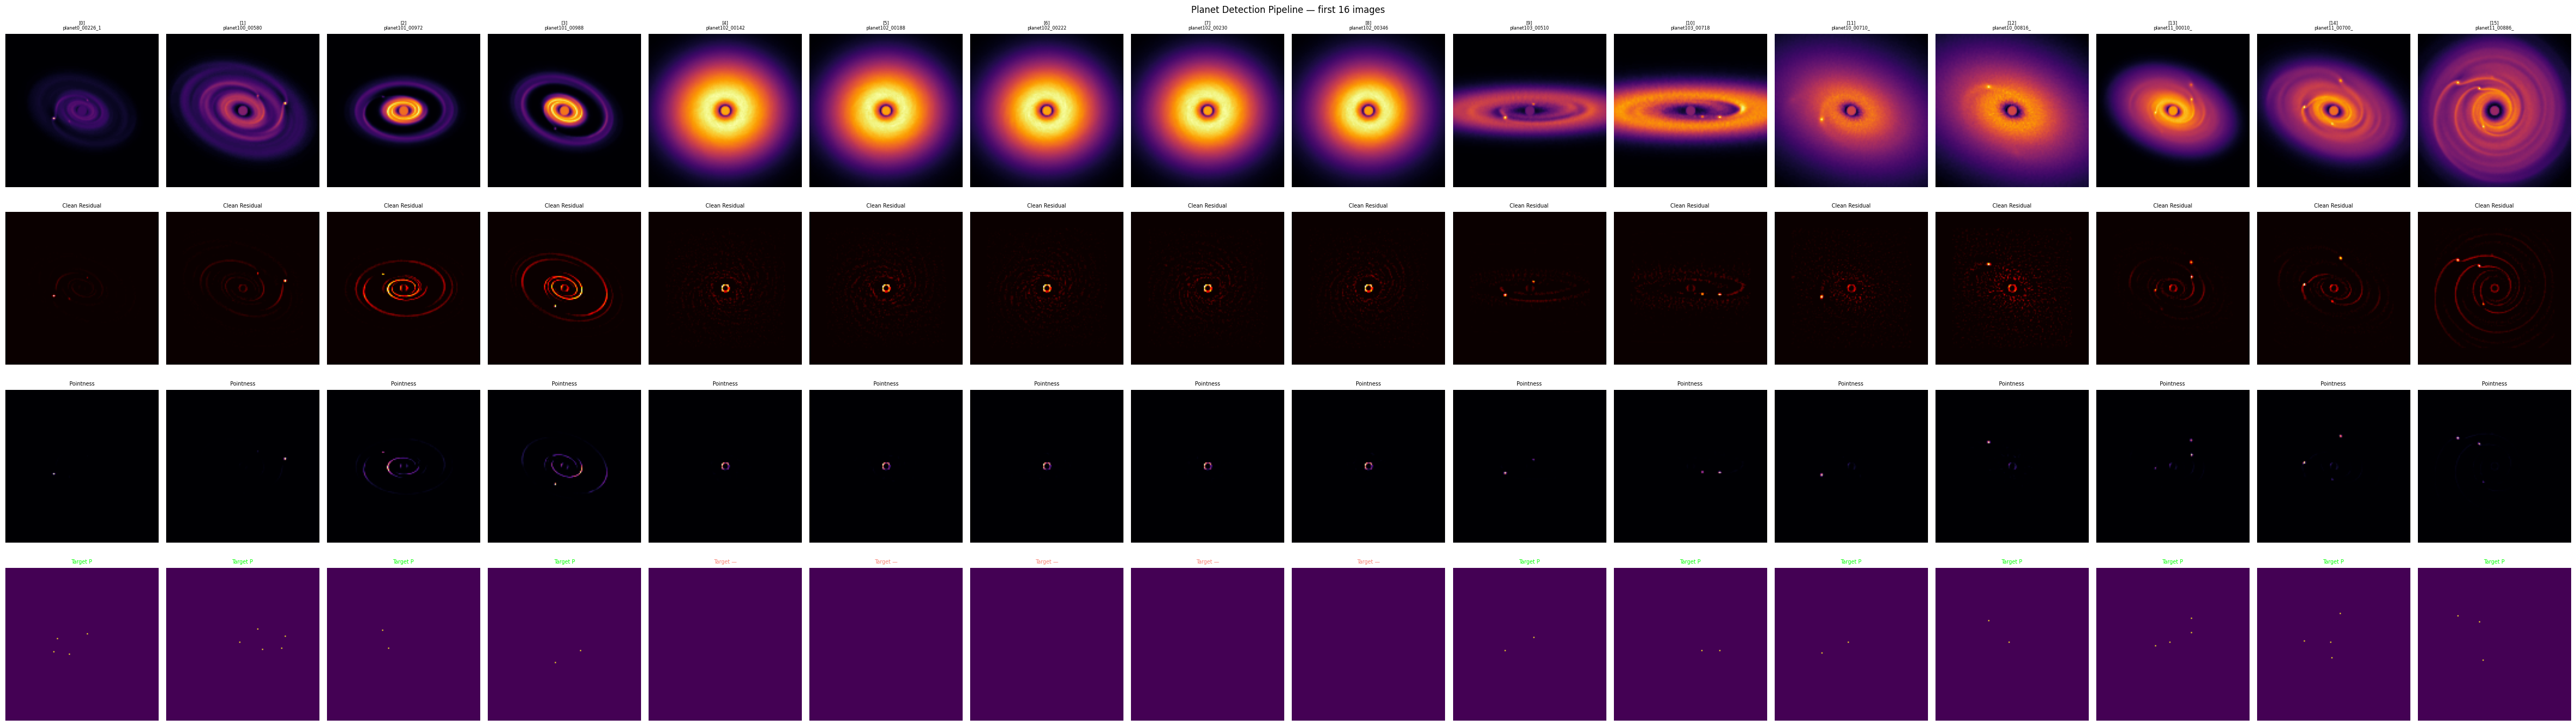

In [9]:
# ── Step 1: Residual extraction ────────────────────────────────────────────
model.eval()
residuals = []

with torch.no_grad():
    for batch in torch.split(images.to(device), 32):
        recon, _, _, _ = model(batch)
        residuals.append((batch - recon).clamp(min=0).cpu())

residuals = torch.cat(residuals)
print("Residual dataset shape:", residuals.shape)


# ── Step 2: Point-source detection pipeline ────────────────────────────────
def _norm01(a):
    a        = a.astype(np.float32)
    mn, mx   = float(a.min()), float(a.max())
    return (a - mn) / (mx - mn + 1e-8)


def build_pointlike_residual_and_target(
    residual, planet_fwhm=3.0, center_mask=12, edge_mask=14,
    max_peaks=8, min_planet_sep=6, debug=False
):
    """
    Extracts point-like planet candidates from a VAE residual map.

    Builds a pointness map via scale-consistent LoG filtering, detects peaks
    above a robust MAD threshold, and rejects false positives caused by ring
    arcs, extended emission, or low contrast. Accepted candidates are returned
    as a soft Gaussian target map.

    Args:
        residual        : (1, H, W) torch tensor — clamped VAE residual
        planet_fwhm     : expected planet FWHM in pixels
        center_mask     : radius (pixels) of the central star exclusion zone
        edge_mask       : border width (pixels) excluded from detection
        max_peaks       : maximum number of planet candidates per image
        min_planet_sep  : minimum separation (pixels) between candidates
        debug           : if True, prints accept/reject decisions per candidate

    Returns:
        clean     : (1, H, W) float tensor — background-subtracted residual
        target    : (1, H, W) float tensor — soft Gaussian planet target map
        pointness : (1, H, W) float tensor — LoG-based point-source map
    """
    def _debug_reject(reason, py, px, **vals):
        if not debug:
            return
        msg = f"REJECT ({py},{px}) → {reason}"
        for k, v in vals.items():
            msg += f", {k}={v:.3f}"
        print(msg)

    def _debug_accept(py, px, **vals):
        if not debug:
            return
        msg = f"ACCEPT ({py},{px})"
        for k, v in vals.items():
            msg += f", {k}={v:.3f}"
        print(msg)

    r      = residual.squeeze().numpy().astype(np.float32)
    h, w   = r.shape
    cy, cx = h // 2, w // 2
    y, x   = np.ogrid[:h, :w]
    dist_c = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    sigma  = planet_fwhm / 2.355

    valid = np.ones((h, w), dtype=bool)
    valid[dist_c < center_mask]  = False
    valid[:edge_mask, :]         = False
    valid[-edge_mask:, :]        = False
    valid[:, :edge_mask]         = False
    valid[:, -edge_mask:]        = False

    # Clean residual: subtract smooth background and local median
    smooth = gaussian_filter(r, sigma=2.5 * sigma)
    clean  = np.clip(r - smooth, 0, None)
    clean  = np.clip(clean - median_filter(clean, size=5), 0, None)
    clean[~valid] = 0
    mn, mx = clean.min(), clean.max()
    clean  = (clean - mn) / (mx - mn + 1e-8)

    # Pointness map: scale-consistent LoG × local peakiness
    log1           = np.clip(-gaussian_laplace(clean, sigma=sigma)          * sigma          ** 2, 0, None)
    log2           = np.clip(-gaussian_laplace(clean, sigma=1.6 * sigma)    * (1.6 * sigma)  ** 2, 0, None)
    log_consistent = np.minimum(log1, log2)
    peakiness      = np.clip(clean - gaussian_filter(clean, sigma=2.2 * sigma), 0, None)
    pointness      = log_consistent * peakiness
    mn, mx         = pointness.min(), pointness.max()
    pointness      = (pointness - mn) / (mx - mn + 1e-8)
    pointness[~valid] = 0

    target = np.zeros_like(pointness, dtype=np.float32)

    vals = pointness[valid & (pointness > 0)]
    if vals.size == 0:
        return (torch.from_numpy(clean).unsqueeze(0).float(),
                torch.from_numpy(target).unsqueeze(0).float(),
                torch.from_numpy(pointness).unsqueeze(0).float())

    med = np.median(vals)
    mad = np.median(np.abs(vals - med)) + 1e-8
    thr = max(np.percentile(vals, 99), med + 3.5 * 1.4826 * mad)

    peaks = peak_local_max(
        pointness, min_distance=min_planet_sep,
        threshold_abs=thr, num_peaks=max_peaks, exclude_border=False,
    )

    accepted = []
    for py, px in peaks:
        if not valid[py, px]:
            _debug_reject("invalid region", py, px)
            continue

        cmax = float(pointness[py, px])
        rr   = np.sqrt((x - px) ** 2 + (y - py) ** 2)

        core      = (rr <= 1.8) & valid
        ann       = (rr >= 2.5) & (rr <= 6.0) & valid
        ring_band = (np.abs(dist_c - dist_c[py, px]) <= 1.2) & valid

        if ann.sum() < 20:
            _debug_reject("annulus too small", py, px)
            continue

        cmean        = float(pointness[core].mean()) + 1e-8
        amean        = float(pointness[ann].mean())  + 1e-8
        ann_frac_high = float((pointness[ann] > 0.30 * cmax).mean())
        ring_level   = float(pointness[ring_band].mean())
        core_area_hi = int((pointness[core] > 0.55 * cmax).sum())

        # Ring arc test
        ring_arc_mask          = (np.abs(dist_c - dist_c[py, px]) <= 2.5) & valid
        ring_arc_frac          = float((pointness[ring_arc_mask] > 0.35 * cmax).mean())
        candidate_radius       = float(dist_c[py, px])
        circumference_pixels   = 2 * np.pi * candidate_radius
        ring_thr = 0.22 if circumference_pixels < 60 else (0.18 if circumference_pixels < 120 else 0.14)

        if ring_arc_frac > ring_thr:
            _debug_reject("ring arc", py, px, ring_frac=ring_arc_frac, thr=ring_thr)
            continue

        # Compactness
        py1, py2  = max(0, py - 8), min(h, py + 8)
        px1, px2  = max(0, px - 8), min(w, px + 8)
        patch         = pointness[py1:py2, px1:px2]
        peak_fraction = cmax / (patch.sum() + 1e-8)

        if ring_level / cmax > 0.18:
            _debug_reject("ring contamination", py, px, ratio=ring_level / cmax, thr=0.18)
            continue
        if ann_frac_high > 0.10:
            _debug_reject("bright annulus", py, px, ann_frac=ann_frac_high, thr=0.10)
            continue
        if cmax / amean < 3.8:
            _debug_reject("low contrast", py, px, contrast=cmax / amean, thr=3.8)
            continue
        if not (1 <= core_area_hi <= 8):
            _debug_reject("core size", py, px, area=core_area_hi)
            continue
        if peak_fraction < 0.08:
            _debug_reject("low compactness", py, px, peak_fraction=peak_fraction, thr=0.08)
            continue

        _debug_accept(py, px, contrast=cmax / amean, compactness=peak_fraction)
        accepted.append((py, px, cmax))

    # Non-maximum suppression
    accepted.sort(key=lambda t: t[2], reverse=True)
    kept, r2 = [], float(min_planet_sep ** 2)
    for py, px, sc in accepted:
        if all((py - ky) ** 2 + (px - kx) ** 2 >= r2 for ky, kx, _ in kept):
            kept.append((py, px, sc))

    # Build soft Gaussian target map
    for py, px, _ in kept[:max_peaks]:
        target[py, px] = 1

    if target.max() > 0:
        target = gaussian_filter(target, sigma=max(0.85, 0.65 * sigma))
        target = np.clip(target, 0, 1)
        target[target < 0.20] = 0
        target[~valid]        = 0
        mn, mx = target.min(), target.max()
        if mx > mn:
            target = (target - mn) / (mx - mn)
        target = np.power(target, 0.2)

    return (torch.from_numpy(clean).unsqueeze(0).float(),
            torch.from_numpy(target).unsqueeze(0).float(),
            torch.from_numpy(pointness).unsqueeze(0).float())


# ── Step 3: Build targets ──────────────────────────────────────────────────
residuals_clean_list, planet_targets_list, pointness_maps_list = [], [], []

for r in residuals:
    c, t, p = build_pointlike_residual_and_target(
        r, planet_fwhm=3.0, center_mask=0, edge_mask=14,
        max_peaks=8, min_planet_sep=6, debug=False
    )
    residuals_clean_list.append(c)
    planet_targets_list.append(t)
    pointness_maps_list.append(p)

residuals_clean = torch.stack(residuals_clean_list)
planet_targets  = torch.stack(planet_targets_list)
pointness_maps  = torch.stack(pointness_maps_list)

print("residuals_clean :", residuals_clean.shape)
print("planet_targets  :", planet_targets.shape)
print("pointness_maps  :", pointness_maps.shape)


# ── Step 4: Visual diagnostic ──────────────────────────────────────────────
n_show   = 16
fig, axes = plt.subplots(4, n_show, figsize=(n_show * 3, 14))

for i in range(n_show):
    axes[0, i].imshow(images[i].squeeze().cpu().numpy(), cmap="inferno")
    axes[0, i].set_title(f"[{i}]\n{names[i][:15]}", fontsize=6)
    axes[0, i].axis("off")

    axes[1, i].imshow(residuals_clean[i].squeeze().numpy(), cmap="hot")
    axes[1, i].set_title("Clean Residual", fontsize=7)
    axes[1, i].axis("off")

    axes[2, i].imshow(pointness_maps[i].squeeze().numpy(), cmap="magma")
    axes[2, i].set_title("Pointness", fontsize=7)
    axes[2, i].axis("off")

    t   = planet_targets[i].squeeze().numpy()
    has = "P" if t.max() > 0 else "—"
    axes[3, i].imshow(t, cmap="viridis")
    axes[3, i].set_title(f"Target {has}", fontsize=7,
                          color='lime' if t.max() > 0 else 'salmon')
    axes[3, i].axis("off")

for row, label in enumerate(["Input", "Clean Residual", "Pointness", "Planet Target"]):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=40)

plt.suptitle(f"Planet Detection Pipeline — first {n_show} images", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Interactive Detection Parameter Tuner *(optional utility)*

An interactive widget for visually tuning the detection thresholds. Shows the clean residual, pointness map, planet target map, and accepted/rejected detections side by side for any image. Use this to justify the threshold values set in the config cell.

This cell does not need to run for the main pipeline — the config values are already tuned.

In [10]:
def pipeline_visualizer(
    idx=0,
    planet_fwhm=3.0, center_mask=0, edge_mask=14,
    min_planet_sep=6, max_peaks=8,
    mad_mult=3.5, percentile_thr=99,
    compactness_thr=0.08, contrast_thr=3.8,
    annulus_high_frac_thr=0.10, ring_contamination_thr=0.18,
    core_min=1, core_max=8, faint_thr=0.05,
    pair_brightness_ratio=0.4, group_radius=20,
):
    r      = residuals[idx].squeeze().numpy().astype(np.float32)
    h, w   = r.shape
    cy, cx = h // 2, w // 2
    y, x   = np.ogrid[:h, :w]
    dist_c = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    sigma  = planet_fwhm / 2.355

    valid = np.ones((h, w), dtype=bool)
    valid[dist_c < center_mask] = False
    valid[:edge_mask, :]        = False
    valid[-edge_mask:, :]       = False
    valid[:, :edge_mask]        = False
    valid[:, -edge_mask:]       = False

    smooth = gaussian_filter(r, sigma=2.5 * sigma)
    clean  = np.clip(r - smooth, 0, None)
    clean  = np.clip(clean - median_filter(clean, size=5), 0, None)
    clean[~valid] = 0
    clean  = (clean - clean.min()) / (clean.max() - clean.min() + 1e-8)

    log1           = np.clip(-gaussian_laplace(clean, sigma=sigma) * sigma ** 2, 0, None)
    sigma2         = 1.6 * sigma
    log2           = np.clip(-gaussian_laplace(clean, sigma=sigma2) * sigma2 ** 2, 0, None)
    log_consistent = np.minimum(log1, log2)
    peakiness      = np.clip(clean - gaussian_filter(clean, sigma=2.2 * sigma), 0, None)
    pointness      = log_consistent * peakiness
    pointness      = (pointness - pointness.min()) / (pointness.max() - pointness.min() + 1e-8)
    pointness[~valid] = 0

    vals      = pointness[valid & (pointness > 0)]
    target    = np.zeros_like(pointness)
    accepted  = []
    rejected  = []

    if vals.size > 0:
        med = np.median(vals)
        mad = np.median(np.abs(vals - med)) + 1e-8
        thr = max(np.percentile(vals, percentile_thr), med + mad_mult * 1.4826 * mad)

        peaks = peak_local_max(
            pointness, min_distance=min_planet_sep,
            threshold_abs=thr, num_peaks=max_peaks, exclude_border=False
        )

        candidates = []
        for py, px in peaks:
            if not valid[py, px]:
                rejected.append((py, px, "valid"))
                continue

            cmax = float(pointness[py, px])
            if cmax < faint_thr:
                rejected.append((py, px, "faint"))
                continue

            rr            = np.sqrt((x - px) ** 2 + (y - py) ** 2)
            core          = (rr <= 1.8) & valid
            ann           = (rr >= 2.5) & (rr <= 6.0) & valid
            ring_band     = (np.abs(dist_c - dist_c[py, px]) <= 1.2) & valid

            if ann.sum() < 20:
                rejected.append((py, px, "ann<20"))
                continue

            amean         = float(pointness[ann].mean()) + 1e-8
            contrast      = cmax / amean
            ann_frac_high = float((pointness[ann] > 0.30 * cmax).mean())
            ring_level    = float(pointness[ring_band].mean())
            core_area_hi  = int((pointness[core] > 0.55 * cmax).sum())
            patch         = pointness[max(0, py-8):min(h, py+8), max(0, px-8):min(w, px+8)]
            peak_fraction = cmax / (patch.sum() + 1e-8)

            if peak_fraction < compactness_thr:
                rejected.append((py, px, "compact")); continue
            if contrast < contrast_thr:
                rejected.append((py, px, "contrast")); continue
            if ann_frac_high > annulus_high_frac_thr:
                rejected.append((py, px, "annulus")); continue
            if ring_level / cmax > ring_contamination_thr:
                rejected.append((py, px, "ring")); continue
            if not (core_min <= core_area_hi <= core_max):
                rejected.append((py, px, "core")); continue

            candidates.append((py, px, cmax))

        candidates.sort(key=lambda t: t[2], reverse=True)
        nms_kept, r2 = [], float(min_planet_sep ** 2)
        for py, px, sc in candidates:
            if all((py - ky) ** 2 + (px - kx) ** 2 >= r2 for ky, kx, _ in nms_kept):
                nms_kept.append((py, px, sc))

        n        = len(nms_kept)
        is_ring  = [False] * n
        for i in range(n):
            py_i, px_i, sc_i = nms_kept[i]
            comparable = 0
            for j in range(n):
                if i == j: continue
                py_j, px_j, sc_j = nms_kept[j]
                if np.sqrt((py_i - py_j) ** 2 + (px_i - px_j) ** 2) > group_radius:
                    continue
                if min(sc_i, sc_j) >= pair_brightness_ratio * max(sc_i, sc_j):
                    comparable += 1
            if comparable >= 2:
                is_ring[i] = True

        for i, (py, px, sc) in enumerate(nms_kept):
            if is_ring[i]:
                rejected.append((py, px, "ring-group"))
            else:
                accepted.append((py, px))
                target[py, px] = 1.0

    if target.max() > 0:
        target = gaussian_filter(target, sigma=max(0.85, 0.65 * sigma))
        target = np.clip(target, 0, 1)
        target[target < 0.20] = 0
        target[~valid]        = 0
        mn, mx = target.min(), target.max()
        if mx > mn:
            target = (target - mn) / (mx - mn)
        target = np.power(target, 0.2)

    fig, axs = plt.subplots(1, 5, figsize=(24, 5))
    axs[0].imshow(images[idx].squeeze().cpu().numpy(), cmap="inferno")
    axs[0].set_title("Original");        axs[0].axis("off")
    axs[1].imshow(clean, cmap="hot")
    axs[1].set_title("Clean Residual");  axs[1].axis("off")
    axs[2].imshow(pointness, cmap="magma")
    axs[2].set_title("Pointness");       axs[2].axis("off")
    axs[3].imshow(target, cmap="viridis")
    axs[3].set_title("Planet Target");   axs[3].axis("off")

    axs[4].imshow(images[idx].squeeze().cpu().numpy(), cmap="inferno")
    for py, px in accepted:
        axs[4].scatter(px, py, c="cyan", s=140, marker="+", linewidths=2)
    for py, px, reason in rejected:
        axs[4].scatter(px, py, c="red", s=80, marker="x")
        axs[4].text(px + 1, py + 1, reason, color="red", fontsize=8)
    axs[4].set_title(
        f"Accepted {len(accepted)} | Rejected {len(rejected)} "
        f"(ring-group: {sum(1 for e in rejected if e[2] == 'ring-group')})"
    )
    axs[4].axis("off")
    plt.tight_layout()
    plt.show()


interact(
    pipeline_visualizer,
    idx                    = (0, len(residuals) - 1),
    planet_fwhm            = (2.0,  6.0,  0.2),
    center_mask            = (0,    30,   1),
    edge_mask              = (5,    25,   1),
    min_planet_sep         = (3,    12,   1),
    max_peaks              = (1,    12,   1),
    mad_mult               = (2.0,  6.0,  0.2),
    percentile_thr         = (90,   100,  1),
    compactness_thr        = (0.02, 0.2,  0.01),
    contrast_thr           = (1.0,  8.0,  0.2),
    annulus_high_frac_thr  = (0.02, 0.3,  0.01),
    ring_contamination_thr = (0.05, 0.4,  0.01),
    core_min               = (0,    5,    1),
    core_max               = (5,    15,   1),
    faint_thr              = (0.0,  0.3,  0.01),
    pair_brightness_ratio  = (0.1,  0.9,  0.05),
    group_radius           = (10,   40,   2),
)

interactive(children=(IntSlider(value=0, description='idx', max=149), FloatSlider(value=3.0, description='plan…

<function __main__.pipeline_visualizer(idx=0, planet_fwhm=3.0, center_mask=0, edge_mask=14, min_planet_sep=6, max_peaks=8, mad_mult=3.5, percentile_thr=99, compactness_thr=0.08, contrast_thr=3.8, annulus_high_frac_thr=0.1, ring_contamination_thr=0.18, core_min=1, core_max=8, faint_thr=0.05, pair_brightness_ratio=0.4, group_radius=20)>

## 10. Latent Extraction & Batch Planet Detection

I extract two core data structures needed for clustering:

**Latent vectors Z** : passes all images through the frozen encoder and collects μ, giving a 128-dimensional morphology descriptor per image. These vectors capture ring shape, gap structure, and brightness profile without any planet contribution.

**Planet detections** : applies the same detection logic from the previous block across the full dataset using the config thresholds, producing `stage1_planetary_detections` , a per-image list of accepted candidate coordinates and scores.

In [11]:
# ── Hyperparameters (tuned via Block 5a) ──────────────────────────────────
PLANET_FWHM            = 3.0
CENTER_MASK            = 0
EDGE_MASK              = 2
MIN_PLANET_SEP         = 2
MAX_PEAKS              = 8
MAD_MULT               = 3.6
PERCENTILE_THR         = 99
COMPACTNESS_THR        = 0.19
CONTRAST_THR           = 3.8
ANNULUS_HIGH_FRAC_THR  = 0.10
RING_CONTAMINATION_THR = 0.18
CORE_MIN               = 1
CORE_MAX               = 8
FAINT_THR              = 0.01
PAIR_BRIGHTNESS_RATIO  = 0.4
GROUP_RADIUS           = 2


# ── 1. Extract latent vectors ──────────────────────────────────────────────
model.eval()
Z_list = []

with torch.no_grad():
    for batch in torch.split(images.to(device), 32):
        _, mu, _, _ = model(batch)
        Z_list.append(mu.cpu().numpy())

Z = np.concatenate(Z_list, axis=0)
print(f"Latent matrix Z shape: {Z.shape}")


# ── 2. Batch planet detection ──────────────────────────────────────────────
stage1_planetary_detections = []
stage1_planetary_features   = []

for i in tqdm(range(len(residuals)), desc="Detecting planets"):
    r      = residuals[i].squeeze().numpy().astype(np.float32)
    h, w   = r.shape
    cy, cx = h // 2, w // 2
    y, x   = np.ogrid[:h, :w]
    dist_c = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    sigma  = PLANET_FWHM / 2.355

    valid = np.ones((h, w), dtype=bool)
    valid[dist_c < CENTER_MASK] = False
    valid[:EDGE_MASK, :]        = False
    valid[-EDGE_MASK:, :]       = False
    valid[:, :EDGE_MASK]        = False
    valid[:, -EDGE_MASK:]       = False

    smooth = gaussian_filter(r, sigma=2.5 * sigma)
    clean  = np.clip(r - smooth, 0, None)
    clean  = np.clip(clean - median_filter(clean, size=5), 0, None)
    clean[~valid] = 0
    clean  = (clean - clean.min()) / (clean.max() - clean.min() + 1e-8)

    log1      = np.clip(-gaussian_laplace(clean, sigma=sigma)         * sigma          ** 2, 0, None)
    log2      = np.clip(-gaussian_laplace(clean, sigma=1.6 * sigma)   * (1.6 * sigma)  ** 2, 0, None)
    peakiness = np.clip(clean - gaussian_filter(clean, sigma=2.2 * sigma), 0, None)
    pointness = np.minimum(log1, log2) * peakiness
    pointness = (pointness - pointness.min()) / (pointness.max() - pointness.min() + 1e-8)
    pointness[~valid] = 0

    vals               = pointness[valid & (pointness > 0)]
    dataset_detections = []

    if vals.size > 0:
        med = np.median(vals)
        mad = np.median(np.abs(vals - med)) + 1e-8
        thr = max(np.percentile(vals, PERCENTILE_THR), med + MAD_MULT * 1.4826 * mad)

        peaks = peak_local_max(
            pointness, min_distance=MIN_PLANET_SEP,
            threshold_abs=thr, num_peaks=MAX_PEAKS, exclude_border=False
        )

        candidates = []
        for py, px in peaks:
            if not valid[py, px]: continue
            cmax = float(pointness[py, px])
            if cmax < FAINT_THR:  continue

            rr            = np.sqrt((x - px) ** 2 + (y - py) ** 2)
            ann           = (rr >= 2.5) & (rr <= 6.0) & valid
            if ann.sum() < 20: continue

            amean         = float(pointness[ann].mean()) + 1e-8
            contrast      = cmax / amean
            ann_frac_high = float((pointness[ann] > 0.30 * cmax).mean())
            ring_level    = float(pointness[(np.abs(dist_c - dist_c[py, px]) <= 1.2) & valid].mean())
            core_val      = int((pointness[max(0, py-2):min(h, py+2),
                                           max(0, px-2):min(w, px+2)] > 0.55 * cmax).sum())
            compactness   = cmax / (pointness[max(0, py-8):min(h, py+8),
                                              max(0, px-8):min(w, px+8)].sum() + 1e-8)

            if compactness   < COMPACTNESS_THR:        continue
            if contrast      < CONTRAST_THR:           continue
            if ann_frac_high > ANNULUS_HIGH_FRAC_THR:  continue
            if ring_level / cmax > RING_CONTAMINATION_THR: continue
            if not (CORE_MIN <= core_val <= CORE_MAX): continue

            candidates.append((py, px, cmax))

        candidates.sort(key=lambda t: t[2], reverse=True)
        nms_kept = []
        for py, px, sc in candidates:
            if all((py - ky) ** 2 + (px - kx) ** 2 >= MIN_PLANET_SEP ** 2
                   for ky, kx, _ in nms_kept):
                nms_kept.append((py, px, sc))

        n       = len(nms_kept)
        is_ring = [False] * n
        for k in range(n):
            py_k, px_k, sc_k = nms_kept[k]
            comparable = sum(
                1 for j in range(n)
                if j != k
                and np.sqrt((py_k - nms_kept[j][0]) ** 2 + (px_k - nms_kept[j][1]) ** 2) < GROUP_RADIUS
                and min(sc_k, nms_kept[j][2]) >= PAIR_BRIGHTNESS_RATIO * max(sc_k, nms_kept[j][2])
            )
            if comparable >= 2:
                is_ring[k] = True

        dataset_detections = [nms_kept[k] for k in range(n) if not is_ring[k]]

    stage1_planetary_detections.append(dataset_detections)
    stage1_planetary_features.append([{} for _ in dataset_detections])

print(f"Detection complete — {len(stage1_planetary_detections)} images processed.")

Latent matrix Z shape: (150, 128)


Detecting planets: 100%|██████████| 150/150 [00:00<00:00, 181.07it/s]

Detection complete — 150 images processed.


## 11. Hierarchical Clustering & UMAP

I cluster disk images in two stages:

**Primary grouping by planet count**
Images are first split into three groups based on the number of detected planet candidates: 0, 1, or 2+. This gives a physically motivated primary partition.

**Secondary morphological subclustering**
Within each primary group, I apply PCA (to 8 components) followed by GMM with BIC-selected k to find morphological subclusters. Disks in the same subcluster share ring structure independent of their planet count.

**UMAP visualization**
The full 128-dim latent space is projected to 2D with UMAP for visualization, with points coloured by their hierarchical label.

**Finding**
Morphology alone does not reliably separate disks by planet count , most of the latent space shows mixing between planet groups. However, two signals emerge at the extremes: a bottom-right cluster is enriched in planet-bearing disks, suggesting those morphologies are associated with planet formation activity. Results are saved to `planetary_morphology_clusters_gmm.csv`.

Latent space dimensions: (150, 128)

--- Primary Grouping ---
  0 Planets: 47 images
  1 Planet: 61 images
  Multi (2+) Planets: 42 images

--- Secondary Clustering ---
  0 Planets: PCA 128→8 dims (97.9% variance explained)
    → k=5  BIC=-1099.64
  1 Planet: PCA 128→8 dims (95.2% variance explained)
    → k=3  BIC=-1112.33
  Multi (2+) Planets: PCA 128→8 dims (95.9% variance explained)
    → k=2  BIC=-757.40

Saved results to 'planetary_morphology_clusters_gmm.csv'


c:\Users\divya\local\Documents\vs code\gsoc\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


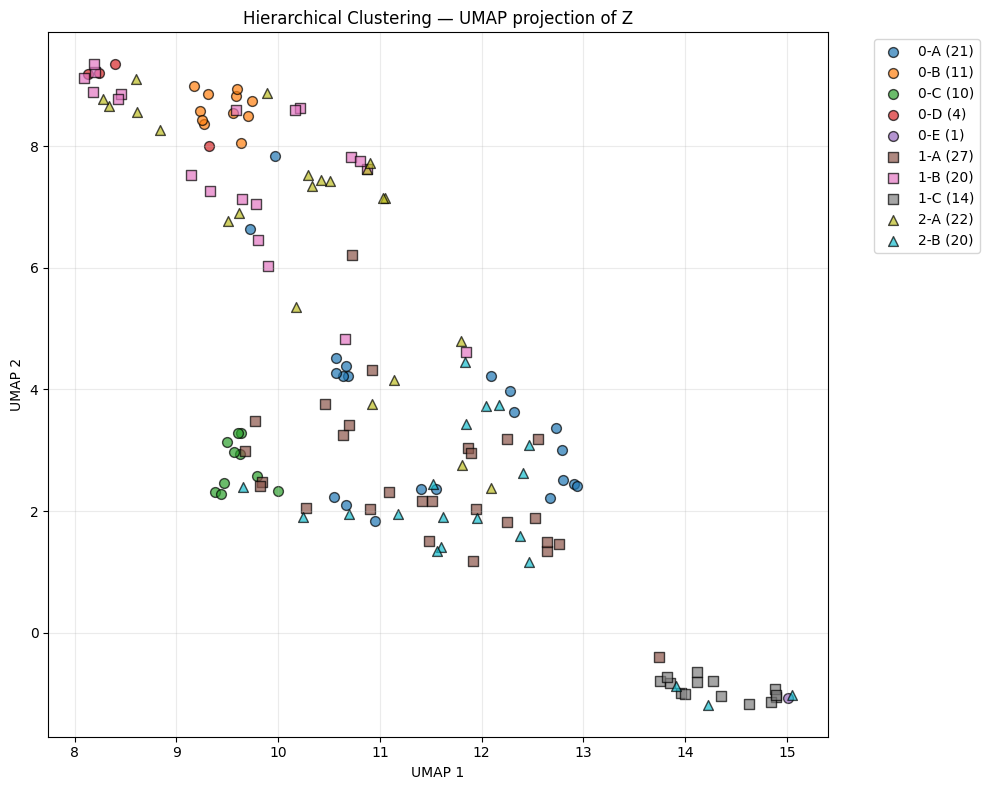

In [12]:
# ── Configuration ──────────────────────────────────────────────────────────
SUBCLUSTER_MAX_K = {0: 5, 1: 5, 2: 5}
MIN_SAMPLES_FOR_CLUSTERING    = 5
PCA_COMPONENTS_FOR_CLUSTERING = 8
RANDOM_SEED                   = 42

required_vars = ["stage1_planetary_detections", "Z", "names"]
missing       = [v for v in required_vars if v not in globals()]

if missing:
    print(f"Missing required variables: {missing}")
else:
    n_samples     = len(stage1_planetary_detections)
    planet_counts = np.array([len(d) for d in stage1_planetary_detections])
    label_names   = {0: "0 Planets", 1: "1 Planet", 2: "Multi (2+) Planets"}

    # ── 1. Primary grouping by planet count ───────────────────────────────
    primary_labels                      = np.zeros(n_samples, dtype=int)
    primary_labels[planet_counts == 1]  = 1
    primary_labels[planet_counts >= 2]  = 2

    print(f"Latent space dimensions: {Z.shape}")
    print("\n--- Primary Grouping ---")
    for lbl in sorted(label_names):
        print(f"  {label_names[lbl]}: {np.sum(primary_labels == lbl)} images")

    # ── 2. Secondary clustering: PCA → GMM + BIC ──────────────────────────
    final_sub_labels = np.array([""] * n_samples, dtype="U10")
    sub_cluster_ids  = np.full(n_samples, -1, dtype=int)

    print("\n--- Secondary Clustering ---")
    for p_lbl in sorted(label_names):
        idxs    = np.where(primary_labels == p_lbl)[0]
        n_group = len(idxs)

        final_sub_labels[idxs] = f"{p_lbl}-A"
        sub_cluster_ids[idxs]  = 0

        if n_group < MIN_SAMPLES_FOR_CLUSTERING:
            print(f"  {label_names[p_lbl]}: too few samples ({n_group}), skipping.")
            continue

        Z_subset = Z[idxs]
        n_pca    = min(PCA_COMPONENTS_FOR_CLUSTERING, n_group - 1, Z_subset.shape[1])

        if n_pca > 1:
            pca     = PCA(n_components=n_pca, random_state=RANDOM_SEED)
            Z_input = pca.fit_transform(Z_subset)
            print(f"  {label_names[p_lbl]}: PCA {Z_subset.shape[1]}→{n_pca} dims "
                  f"({np.sum(pca.explained_variance_ratio_):.1%} variance explained)")
        else:
            Z_input = Z_subset

        best_bic, best_k, best_gmm = float('inf'), 1, None
        for k in range(1, min(SUBCLUSTER_MAX_K[p_lbl], n_group) + 1):
            try:
                cov_type = 'full' if n_group > k * n_pca * 2 else 'diag'
                gmm      = GaussianMixture(n_components=k, covariance_type=cov_type,
                                           random_state=RANDOM_SEED, n_init=10, reg_covar=1e-4)
                gmm.fit(Z_input)
                bic = gmm.bic(Z_input)
                if bic < best_bic:
                    best_bic, best_k, best_gmm = bic, k, gmm
            except Exception:
                pass

        if best_gmm is not None:
            print(f"    → k={best_k}  BIC={best_bic:.2f}")
            sub_lbls  = best_gmm.predict(Z_input)
            u, counts_sub = np.unique(sub_lbls, return_counts=True)
            mapping   = {v: i for i, v in enumerate(u[np.argsort(-counts_sub)])}
            for i, sub in enumerate(sub_lbls):
                ordered = mapping[sub]
                final_sub_labels[idxs[i]] = f"{p_lbl}-{chr(ord('A') + ordered)}"
                sub_cluster_ids[idxs[i]]  = ordered
        else:
            print(f"    → fallback to k=1")

    # ── 3. Save results ────────────────────────────────────────────────────
    csv_path = "planetary_morphology_clusters_gmm.csv"
    try:
        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["idx", "name", "n_planets", "primary_group",
                              "sub_group_label"] + [f"z_{i}" for i in range(Z.shape[1])])
            for i in range(n_samples):
                writer.writerow([i, names[i] if i < len(names) else f"img_{i}",
                                  planet_counts[i], int(primary_labels[i]),
                                  final_sub_labels[i]] + list(Z[i]))
        print(f"\nSaved results to '{csv_path}'")
    except Exception as e:
        print(f"Error saving CSV: {e}")

    # ── 4. UMAP Visualization ──────────────────────────────────────────────
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=RANDOM_SEED)
    Z_viz   = reducer.fit_transform(Z)

    plt.figure(figsize=(10, 8))
    for u_lbl in sorted(np.unique(final_sub_labels)):
        grp    = int(u_lbl.split('-')[0])
        marker = 'o' if grp == 0 else ('s' if grp == 1 else '^')
        mask   = (final_sub_labels == u_lbl)
        if np.any(mask):
            plt.scatter(Z_viz[mask, 0], Z_viz[mask, 1],
                        label=f"{u_lbl} ({np.sum(mask)})",
                        alpha=0.7, s=50, edgecolors='k', marker=marker)

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("Hierarchical Clustering — UMAP projection of Z")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

## 12. Interactive Cluster Image Viewer *(optional utility)*

Browse all disk images within each GMM morphological subcluster using a dropdown. Detected planet candidates are overlaid as cyan circles. Useful for visually verifying what structural characteristics each subcluster has captured and whether the clustering reflects physically meaningful groupings.

In [ ]:
COLS = 6

def view_cluster_subgroups(primary_group):
    label_map = {"0 Planets": 0, "1 Planet": 1, "Multi (2+) Planets": 2}
    p_id      = label_map[primary_group]

    if "final_sub_labels" not in globals():
        print("Error: run the clustering block first.")
        return

    relevant_subs = sorted([l for l in np.unique(final_sub_labels)
                             if l.startswith(f"{p_id}-")])
    if not relevant_subs:
        print(f"No samples found for group {p_id}.")
        return

    # Subcluster colour accents for title bars
    accent_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
                     '#8c564b','#e377c2','#7f7f7f']

    for s_idx, sub_lbl in enumerate(relevant_subs):
        idxs   = np.where(final_sub_labels == sub_lbl)[0]
        n_show = len(idxs)
        if n_show == 0:
            continue

        rows   = (n_show + COLS - 1) // COLS
        color  = accent_colors[s_idx % len(accent_colors)]

        fig    = plt.figure(figsize=(3.2 * COLS, 3.4 * rows + 0.6))
        fig.patch.set_facecolor('#0f0f0f')

        # Title banner
        fig.suptitle(
            f"Sub-Cluster  {sub_lbl}    ·    {n_show} images    ·    "
            f"{'0 Planets' if p_id == 0 else ('1 Planet' if p_id == 1 else '2+ Planets')}",
            fontsize=13, fontweight='bold', color=color,
            y=1.01, x=0.5
        )

        for i, img_idx in enumerate(idxs):
            ax = fig.add_subplot(rows, COLS, i + 1)

            img_data = (images[img_idx].cpu().squeeze().numpy()
                        if isinstance(images, torch.Tensor)
                        else images[img_idx].squeeze())

            ax.imshow(img_data, cmap='inferno', origin='upper')

            # Overlay detected planets if available
            if 'stage1_planetary_detections' in globals():
                dets = stage1_planetary_detections[img_idx]
                for (py, px, sc) in dets:
                    ax.scatter(px, py, s=120, facecolors='none',
                               edgecolors='cyan', linewidths=1.5)

            short_name = names[img_idx].replace('.fits', '')[-18:]
            ax.set_title(f"[{img_idx}]  {short_name}", fontsize=7,
                         color='#cccccc', pad=3)
            ax.axis('off')

            # Coloured border matching cluster accent
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(1.2)
                spine.set_visible(True)

        # Hide unused axes
        total_axes = rows * COLS
        for j in range(n_show, total_axes):
            ax = fig.add_subplot(rows, COLS, j + 1)
            ax.set_facecolor('#0f0f0f')
            ax.axis('off')

        plt.tight_layout()
        plt.show()
        print()


interact(
    view_cluster_subgroups,
    primary_group=widgets.Dropdown(
        options=["0 Planets", "1 Planet", "Multi (2+) Planets"],
        value="0 Planets",
        description="Cluster:",
        style={'description_width': 'initial'}
    )
)

interactive(children=(Dropdown(description='Cluster:', options=('0 Planets', '1 Planet', 'Multi (2+) Planets')…

<function __main__.view_cluster_subgroups(primary_group)>

## Files Generated

| File | Description |
|---|---|
| `disk_vae_checkpoint.pth` | Trained DiskVAE weights · optimizer state · epoch · latent dim |
| `planetary_morphology_clusters_gmm.csv` | Per-image results: planet count · primary group · subcluster label · full 128-dim latent vector |

### Variables available after running

| Variable | Shape | Description |
|---|---|---|
| `images` | (N, 1, 128, 128) | All preprocessed disk images |
| `names` | list[str] | Filenames corresponding to each image |
| `residuals` | (N, 1, 128, 128) | VAE reconstruction residuals |
| `Z` | (N, 128) | Latent vectors μ for all images |
| `stage1_planetary_detections` | list[list] | Accepted planet candidates per image |
| `primary_labels` | (N,) | Primary group: 0 / 1 / 2+ planets |
| `final_sub_labels` | (N,) | Hierarchical subcluster labels e.g. 0-A, 1-B |
| `Z_viz` | (N, 2) | 2D UMAP projection of latent space |